# LOAD DATSET

In [5]:
from google.colab import files
uploaded = files.upload()

Saving survey.csv to survey.csv


In [10]:
import pandas as pd

df = pd.read_csv("survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [11]:
df.shape
df.columns
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [12]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


# IMPORT LIBARIES

In [16]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing (feature engineering)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# EDA

In [52]:
pd.crosstab(df['benefits'], df['treatment'], normalize='index') * 100

treatment,No,Yes
benefits,,
Don't know,62.990196,37.009804
No,51.604278,48.395722
Yes,36.058700,63.941300


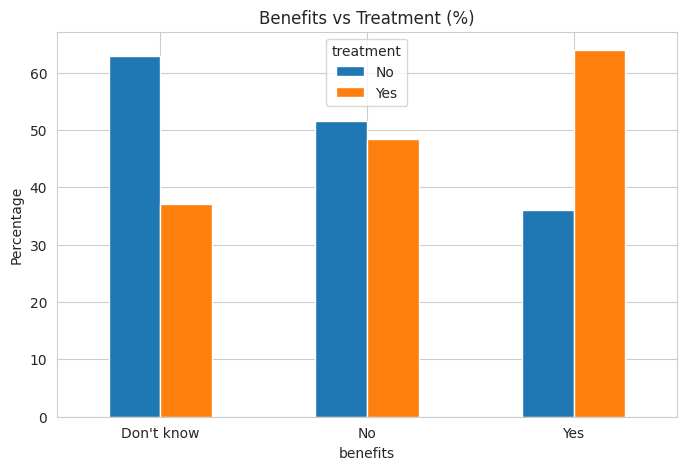

In [53]:
ct = pd.crosstab(df['benefits'], df['treatment'], normalize='index') * 100

ct.plot(kind='bar')

plt.title("Benefits vs Treatment (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

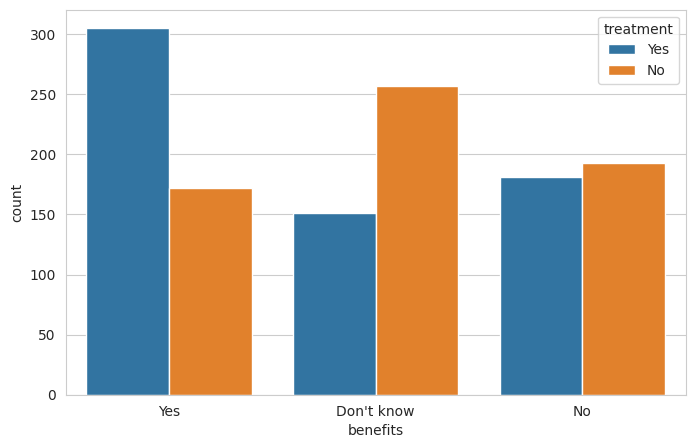

In [42]:
sns.countplot(x='benefits', hue='treatment', data=df)
plt.show()

In [43]:
pd.crosstab(df['seek_help'], df['treatment'], normalize='index') * 100

treatment,No,Yes
seek_help,,
Don't know,54.269972,45.730028
No,50.000000,50.000000
Yes,40.800000,59.200000


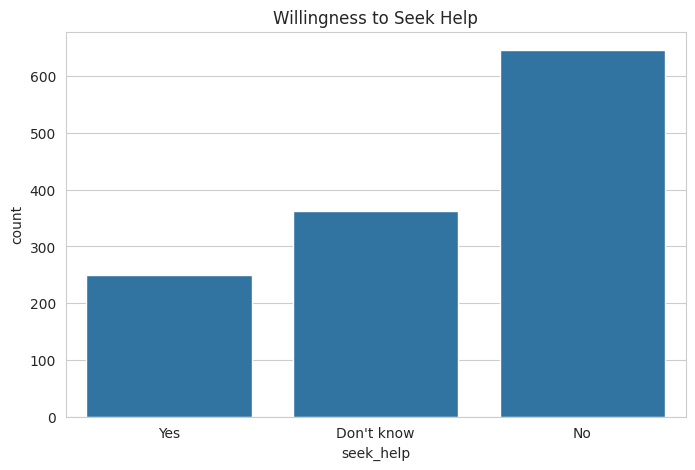

In [44]:
sns.countplot(x='seek_help', data=df)
plt.title("Willingness to Seek Help")
plt.show()

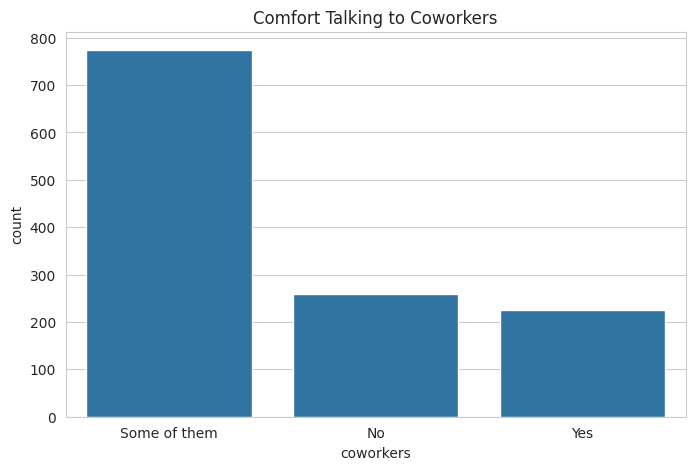

In [45]:
sns.countplot(x='coworkers', data=df)
plt.title("Comfort Talking to Coworkers")
plt.show()

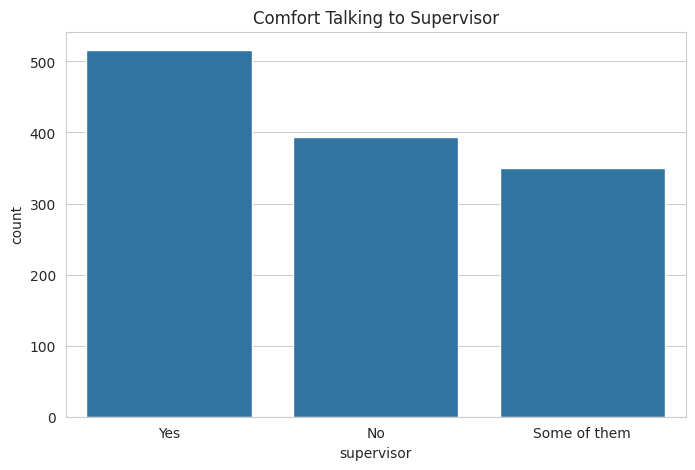

In [46]:
sns.countplot(x='supervisor', data=df)
plt.title("Comfort Talking to Supervisor")
plt.show()

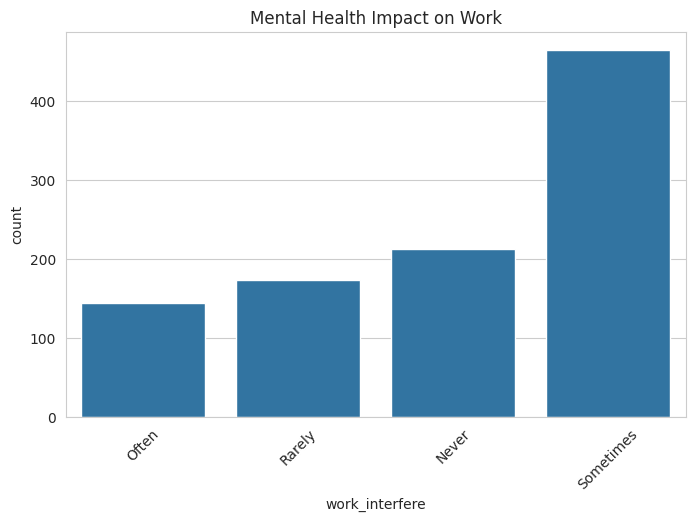

In [47]:
sns.countplot(x='work_interfere', data=df)
plt.xticks(rotation=45)
plt.title("Mental Health Impact on Work")
plt.show()

In [48]:
pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100

treatment,No,Yes
work_interfere,,
Never,85.915493,14.084507
Often,14.583333,85.416667
Rarely,29.479769,70.520231
Sometimes,23.010753,76.989247


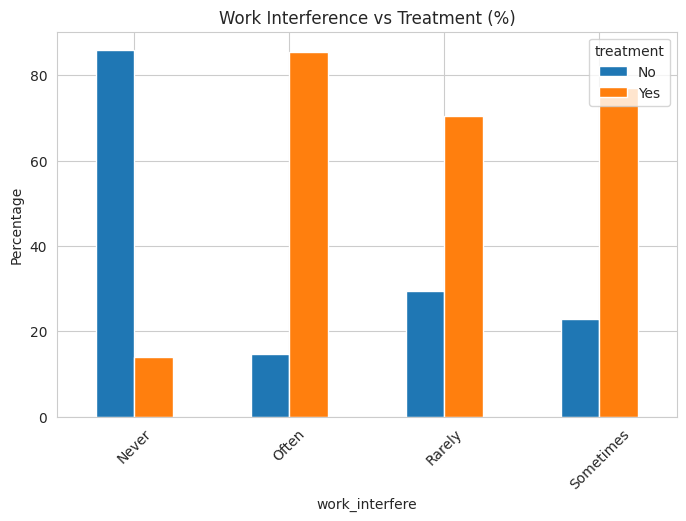

In [49]:
ct = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100

ct.plot(kind='bar')
plt.title("Work Interference vs Treatment (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

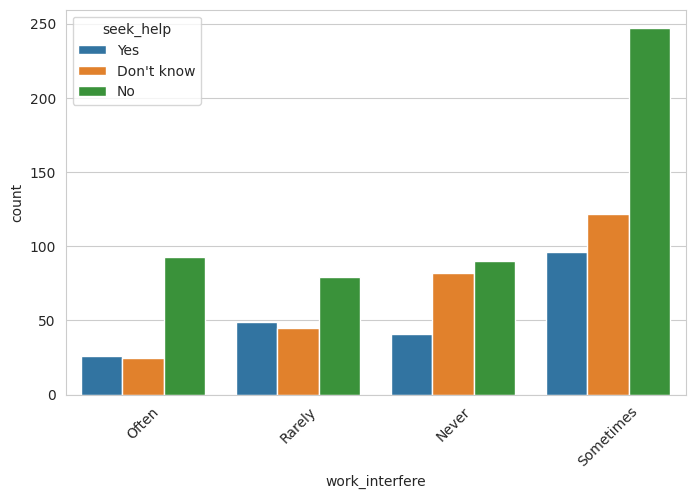

In [50]:
sns.countplot(x='work_interfere', hue='seek_help', data=df)
plt.xticks(rotation=45)
plt.show()


# KEY INSIGHTS

 1. Do Benefits Increase Help-Seeking?

> Employees with access to mental health benefits are significantly more likely to seek treatment (~65%) compared to those without benefits (~48%) or unaware (~37%).
> This highlights that both **availability and awareness of benefits** play a crucial role in encouraging help-seeking behavior.

---

 2. Are Employees Afraid to Talk?

> A large proportion of employees are hesitant or unsure about seeking help, with many responding “No” or “Don’t know.”
> While some employees feel comfortable discussing mental health with coworkers, fewer feel the same with supervisors, indicating **workplace stigma and hierarchical communication barriers**.

---

 3. Does Mental Health Affect Work?

> Mental health significantly impacts work productivity, with many employees reporting interference “sometimes” or “often.”
> Treatment-seeking behavior increases sharply as work interference rises (up to ~85%), suggesting employees tend to act **only when productivity is affected** rather than seeking early support.


